In [1]:
# Import all relevant libraries
# This libraries will provides the data structures,
# numerical operations, and visualization tools
# to handle structured or tabular data.

import pandas as pd # provide the data structures i.e. DataFrame
import numpy as np # use for numeric computations
import matplotlib.pyplot as plt # for visualiztion
import seaborn as sns # visualization

In [2]:
# Extract data from excel file
def get_data(data_path):
    df = pd.read_excel(data_path)
    return df

def count_missing_values(df):
    return df.isna().sum()

def remove_missing_values(df, columns=None):
    # no columns specify (default)
    if columns == None:
        return
        
    # columns should be a list
    return df.dropna(subset=columns, inplace=True)


In [3]:
file_path = r"Provenance Trial 2026 data.xlsx"

df = get_data(file_path)
df.head()

,No.,Day,Months,Year,Monitoring_team,Planting_year,Plot,Provenance,Provenance2,Line_number,Tree_number,Total_height,Merchantable_height,DBH,Number_shoots,Flowering,Remarks,H/D,TH vs MH
0,1,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,1,1,19.8,9,24.3,NaN,NaN,NaN,0.814815,1.0
1,2,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,1,2,thinned,thinned,thinned,NaN,NaN,NaN,NaN,NaN
2,3,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,1,3,dead,dead,dead,NaN,NaN,NaN,NaN,NaN
3,4,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,1,4,21,11,26.7,NaN,NaN,NaN,0.786517,1.0
4,5,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,1,5,dead,dead,dead,NaN,NaN,NaN,NaN,NaN


In [4]:
count_missing_values(df)

No.                       0
Day                       1
Months                    1
Year                      0
Monitoring_team           0
Planting_year             0
Plot                      0
Provenance             9863
Provenance2               0
Line_number               0
Tree_number               0
Total_height             76
Merchantable_height      76
DBH                       0
Number_shoots          9863
Flowering              9843
Remarks                8349
H/D                    4992
TH vs MH               4991
dtype: int64

In [5]:
# remove missing values from height columns
cols = ['Total_height', 'Merchantable_height'] 
remove_missing_values(df, cols)

# check if the missing values are removed
count_missing_values(df)

No.                       0
Day                       1
Months                    1
Year                      0
Monitoring_team           0
Planting_year             0
Plot                      0
Provenance             9787
Provenance2               0
Line_number               0
Tree_number               0
Total_height              0
Merchantable_height       0
DBH                       0
Number_shoots          9787
Flowering              9767
Remarks                8349
H/D                    4992
TH vs MH               4991
dtype: int64

In [6]:
# Check for any data that need to be removed from height and dbh
height = 'Total_height'
height2 = 'Merchantable_height'
dbh = 'DBH'

df[[height, height2, dbh]].values

array([[19.8, 9, 24.3],
       ['thinned', 'thinned', 'thinned'],
       ['dead', 'dead', 'dead'],
       ...,
       ['thinned', 'thinned', 'thinned'],
       [13.25, 6.75, 16.2],
       [13, 8.754, 17.5]], shape=(9787, 3), dtype=object)

In [7]:
# remove thinned and dead trees 
thin_dead = ['Thinned', 'thinned', 'dead']
df = df[~df[[height, height2, dbh]].isin(thin_dead).any(axis=1)]

In [8]:
df[[height, height2, dbh]].values

array([[19.8, 9, 24.3],
       [21, 11, 26.7],
       [20, 9.3, 27.8],
       ...,
       [11, 7.75, 10.7],
       [13.25, 6.75, 16.2],
       [13, 8.754, 17.5]], shape=(4795, 3), dtype=object)

In [9]:
# review the remarks column
df['Remarks'].unique()

<ArrowStringArray>
[         nan,     'forked',       'tall',      'short',       'Tall',
 'top broken',    'climber',    'crooked',     'Forked',      'Short']
Length: 10, dtype: str

In [10]:
# remove forked, crooked, and top broken data
unwanted = ['top broken', 'forked', 'Forked', 'crooked']
df = df[~df['Remarks'].isin(unwanted)]

In [11]:
df.head()

,No.,Day,Months,Year,Monitoring_team,Planting_year,Plot,Provenance,Provenance2,Line_number,Tree_number,Total_height,Merchantable_height,DBH,Number_shoots,Flowering,Remarks,H/D,TH vs MH
0,1,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,1,1,19.8,9,24.3,NaN,NaN,NaN,0.814815,1.0
3,4,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,1,4,21,11,26.7,NaN,NaN,NaN,0.786517,1.0
6,7,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,1,7,20,9.3,27.8,NaN,NaN,NaN,0.719424,1.0
8,9,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,2,2,21.3,10.3,22.8,NaN,NaN,NaN,0.934211,1.0
12,13,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,2,6,19,9,25.7,NaN,NaN,NaN,0.739300,1.0


In [12]:
# Compute Tree ages
df['Age'] = df['Year'] - df['Planting_year']
df.head()

,No.,Day,Months,Year,Monitoring_team,Planting_year,Plot,Provenance,Provenance2,Line_number,Tree_number,Total_height,Merchantable_height,DBH,Number_shoots,Flowering,Remarks,H/D,TH vs MH,Age
0,1,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,1,1,19.8,9,24.3,NaN,NaN,NaN,0.814815,1.0,11
3,4,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,1,4,21,11,26.7,NaN,NaN,NaN,0.786517,1.0,11
6,7,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,1,7,20,9.3,27.8,NaN,NaN,NaN,0.719424,1.0,11
8,9,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,2,2,21.3,10.3,22.8,NaN,NaN,NaN,0.934211,1.0,11
12,13,26.0,3.0,2026,"Emmanuel,Rich,Evelyn,Grace",2015,1,NaN,AS1,2,6,19,9,25.7,NaN,NaN,NaN,0.739300,1.0,11


In [13]:
# check for H/D ratio less than 30
df[df['H/D'] < 30].value_counts()

Series([], Name: count, dtype: int64)

In [14]:
# Extract relevant features for analysis
features = ['Plot', 'Provenance2', 'Tree_number', height, height2, dbh, 'Age']
df = df[features]
df.head()

,Plot,Provenance2,Tree_number,Total_height,Merchantable_height,DBH,Age
0,1,AS1,1,19.8,9,24.3,11
3,1,AS1,4,21,11,26.7,11
6,1,AS1,7,20,9.3,27.8,11
8,1,AS1,2,21.3,10.3,22.8,11
12,1,AS1,6,19,9,25.7,11


In [15]:
# Compute stems per hectare (SPHA)

# stems per plot
spplt = df.groupby(['Provenance2','Plot']).size().reset_index(name='stems_per_plot')
plot_size = (21*21)/10000

spplt['stems_per_ha'] = spplt['stems_per_plot'] / plot_size

In [16]:
spplt.head()

,Provenance2,Plot,stems_per_plot,stems_per_ha
0,64,18,19,430.839002
1,64,21,10,226.757370
2,64,78,16,362.811791
3,64,90,4,90.702948
4,64,102,14,317.460317


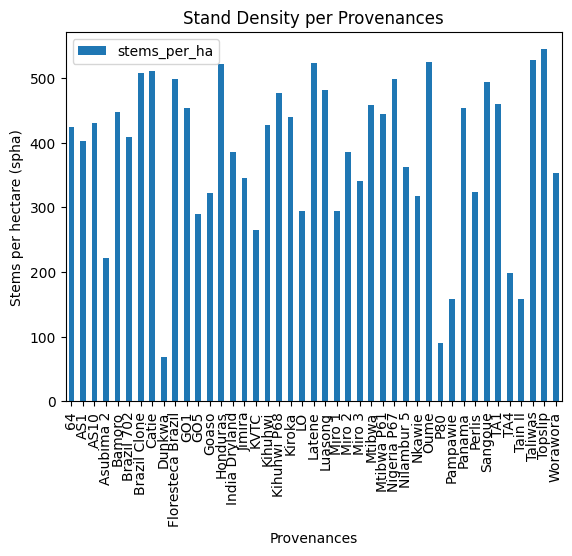

In [17]:
prov_summary = spplt.groupby('Provenance2')['stems_per_ha'].mean().reset_index()
prov_summary.plot(kind='bar', x='Provenance2', y='stems_per_ha')
plt.xlabel("Provenances")
plt.ylabel("Stems per hectare (spha)")
plt.title("Stand Density per Provenances")
plt.show()

In [18]:
# Compute Basal Area per hectare
df['basal_area_m2'] = (np.pi * (df[dbh]/100)**2)/4
df.head()


,Plot,Provenance2,Tree_number,Total_height,Merchantable_height,DBH,Age,basal_area_m2
0,1,AS1,1,19.8,9,24.3,11,0.046377
3,1,AS1,4,21,11,26.7,11,0.05599
6,1,AS1,7,20,9.3,27.8,11,0.060699
8,1,AS1,2,21.3,10.3,22.8,11,0.040828
12,1,AS1,6,19,9,25.7,11,0.051875


In [19]:
# basal area per plot
ba_plot = df.groupby(['Provenance2', 'Plot'])['basal_area_m2'].sum().reset_index()
ba_plot['ba_per_ha'] = ba_plot['basal_area_m2'] / plot_size

ba_plot.head()

,Provenance2,Plot,basal_area_m2,ba_per_ha
0,64,18,0.373664,8.47311
1,64,21,0.139292,3.158547
2,64,78,0.469652,10.649714
3,64,90,0.092829,2.104974
4,64,102,0.312388,7.083632


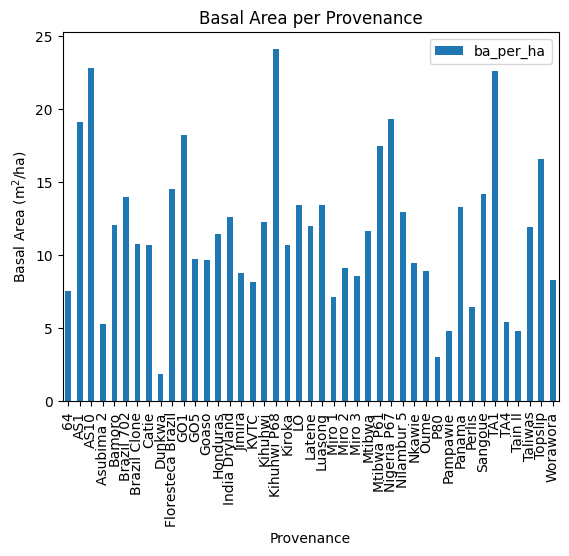

In [20]:
# plot basal area per hectare per provenance
ba_prov = ba_plot.groupby('Provenance2')['ba_per_ha'].mean().reset_index()
ba_prov.plot(kind='bar', x='Provenance2', y='ba_per_ha')
plt.xlabel('Provenance')
plt.ylabel('Basal Area (m$^2$/ha)')
plt.title("Basal Area per Provenance")
plt.show()

In [21]:
df.head()

,Plot,Provenance2,Tree_number,Total_height,Merchantable_height,DBH,Age,basal_area_m2
0,1,AS1,1,19.8,9,24.3,11,0.046377
3,1,AS1,4,21,11,26.7,11,0.05599
6,1,AS1,7,20,9.3,27.8,11,0.060699
8,1,AS1,2,21.3,10.3,22.8,11,0.040828
12,1,AS1,6,19,9,25.7,11,0.051875


In [23]:
ba_age = df.groupby(['Age', 'Provenance2'])['basal_area_m2'].sum().reset_index()
ba_age.head()

,Age,Provenance2,basal_area_m2
0,6,64,1.466878
1,6,Brazil Clone,1.44543
2,6,Latene,1.59607
3,6,Oume,1.173652
4,7,64,1.631792


In [24]:
ba_age['ba_per_ha'] = ba_age['basal_area_m2'] / plot_size
ba_age.head()

,Age,Provenance2,basal_area_m2,ba_per_ha
0,6,64,1.466878,33.262538
1,6,Brazil Clone,1.44543,32.776197
2,6,Latene,1.59607,36.192073
3,6,Oume,1.173652,26.613422
4,7,64,1.631792,37.002084


In [25]:
ba_6 = ba_age[ba_age['Age'] == 6]
ba_6

,Age,Provenance2,basal_area_m2,ba_per_ha
0,6,64,1.466878,33.262538
1,6,Brazil Clone,1.44543,32.776197
2,6,Latene,1.59607,36.192073
3,6,Oume,1.173652,26.613422


<Axes: xlabel='Provenance2'>

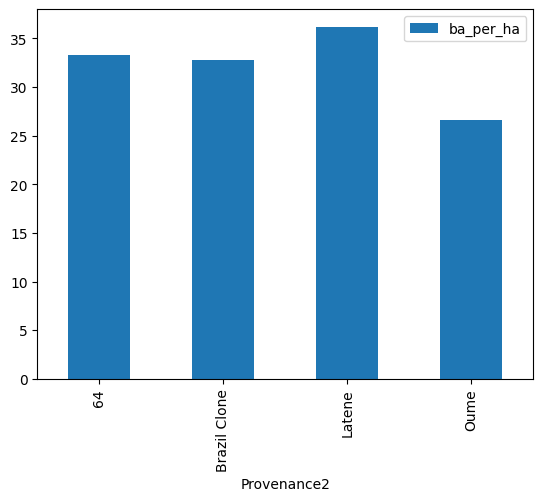

In [26]:
ba_6.plot(kind='bar', x='Provenance2', y='ba_per_ha')

In [27]:
ba_age['Age'].unique()

array([ 6,  7,  8,  9, 10, 11])

<Axes: xlabel='Provenance2'>

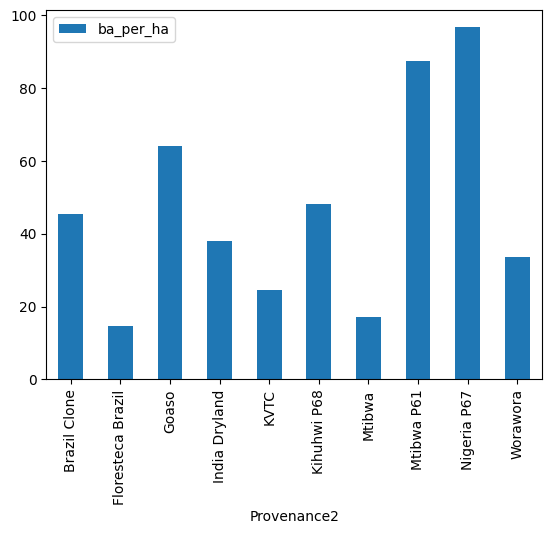

In [28]:
ba_9 = ba_age[ba_age['Age'] == 9]
ba_9.plot(kind='bar', x='Provenance2', y='ba_per_ha')